In [1]:
import numpy as np
from matplotlib import pyplot as plt
import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd # Pour un affichage propre du tableau
from datetime import datetime

# --- 1. Définition de l'Architecture (Obligatoire avant chargement) ---
class MVDR_FFNN(nn.Module):
    def __init__(self):
        super(MVDR_FFNN, self).__init__()
        self.layer1 = nn.Linear(3, 512)
        self.layer2 = nn.Linear(512, 1024)
        self.layer3 = nn.Linear(1024, 2048)
        self.layer4 = nn.Linear(2048, 1024)
        self.layer5 = nn.Linear(1024, 32) # Dernière couche 
        
    def forward(self, x):
        # 1. Les L-1 premières couches cachées utilisent Tanh ou leaky_relu  x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
               
        x = self.layer5(x)        
        return x

# --- 2. Configuration du Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. Initialisation et Chargement Dynamique ---
model = MVDR_FFNN().to(device)

# On définit le dossier de recherche
checkpoint_dir = "../models_FFNN"
search_pattern = os.path.join(checkpoint_dir, "*.pth")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    raise FileNotFoundError(f"⚠️ Aucun fichier .pth trouvé dans {checkpoint_dir}")

# Sélection du fichier le plus récent (basé sur le temps de création)
latest_model_path = max(list_of_files, key=os.path.getctime)

# Chargement des poids
# map_location=device permet de basculer de GPU à CPU sans erreur
checkpoint = torch.load(latest_model_path, map_location=device, weights_only=True)
model.load_state_dict(checkpoint)

# --- 4. Mise en mode Évaluation ---
model.eval()

print("-" * 50)
print(f"✅ MODÈLE CHARGÉ : {os.path.basename(latest_model_path)}")
print(f"📍 CHEMIN : {latest_model_path}")
print(f"💻 DEVICE : {device}")
print("-" * 50)

--------------------------------------------------
✅ MODÈLE CHARGÉ : MVDR_FFNN20260330_1057_model.pth
📍 CHEMIN : ../models_FFNN/MVDR_FFNN20260330_1057_model.pth
💻 DEVICE : cuda
--------------------------------------------------


In [5]:
# Génération des 105 Triades Aléatoires (Contrainte 5∘)
def generate_random_test_data(n=105, min_sep=5.0):
    triads = []
    while len(triads) < n:
        soi, soa1, soa2 = np.random.uniform(-60, 60, 3)
        # Vérification des écarts mutuels
        if (abs(soi-soa1) >= min_sep and abs(soi-soa2) >= min_sep and abs(soa1-soa2) >= min_sep):
            triads.append([soi, soa1, soa2])
    return np.array(triads)

test_triads = generate_random_test_data(105)

# Génération des données de test inédites
test_triads = generate_random_test_data(105)
print(f"✅ {len(test_triads)} triades générées avec succès (écart min 5°).")

# =====================================================================================================================================

# --- Parametres du réseau d'antenne pour le MVDR ---
sample_rate = 1e6
K = 10000 
d = 0.5 
Nr = 16 
t = np.arange(K)/sample_rate 

# Puissances
P_soi = 1
P_int1 = 0.5
P_int2 = 1
P_noise = 0.03

def get_steering_vector(theta_deg, Nr=16, d=0.5):
    theta_rad = np.deg2rad(theta_deg)
    n = np.arange(Nr) # Enlever le .reshape(-1, 1) pour avoir un vecteur plat
    return np.exp(2j * np.pi * d * n * np.sin(theta_rad))

theta_scan = np.linspace(-np.pi/2, np.pi/2, 1000)
theta_scan_deg = np.rad2deg(theta_scan)

def get_gain_at_angle(angle_cible, angles_scan, gains_db):
    """
    Trouve le gain (en dB) le plus proche d'un angle donné.
    
    Args:
        angle_cible (float): L'angle que l'on cherche (ex: soi_test).
        angles_scan (array): Le vecteur des angles utilisés pour le plot (theta_scan_deg).
        gains_db (array): Le vecteur des gains calculés (results_mvdr ou gain_db_NN).
        
    Returns:
        float: Le gain correspondant à l'angle le plus proche.
    """
    # 1. Calcul de la différence absolue entre chaque angle du scan et la cible
    differences = np.abs(angles_scan - angle_cible)
    
    # 2. On trouve l'indice où cette différence est minimale
    idx_proche = np.argmin(differences)
    
    # 3. On retourne le gain correspondant à cet indice
    return gains_db[idx_proche]

# --- BOUCLE DE CALCUL POUR LE CSV (105 TRIADES) ---
log_data = []  
all_weights = [] # Nouvelle liste pour stocker les poids complexes
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
angles_scan_NN = np.linspace(-90, 90, 1000)

for idx in range(len(test_triads)):
    soi_test, soa1_test, soa2_test = test_triads[idx]
    
    # 1. PRÉDICTION NN
    with torch.no_grad():
        entree = torch.tensor([[soi_test, soa1_test, soa2_test]], dtype=torch.float32).to(device) / 60.0
        # Correction : ajout de .detach() pour permettre la conversion numpy
        sortie = model(entree).detach().cpu().numpy().flatten()
    
    # 4. NORMALISATION DU VECTEUR DE SORTIE
    norme_ia = np.linalg.norm(sortie)
    sortie_norm = sortie / (norme_ia + 1e-12)
    
    # 5. Reconstruction du vecteur de poids complexe (w)
    w_complex = sortie_norm[:16] + 1j * sortie_norm[16:]
    
    # 6. Calcul du diagramme de rayonnement NN
    puissance = []
    for angle in angles_scan_NN:
        a_theta = get_steering_vector(angle)
        valeur_scalaire = np.vdot(w_complex, a_theta)
        puissance.append(np.abs(valeur_scalaire)**2)
    
    puissance = np.array(puissance)    
    
    # 7. NORMALISATION À 0 dB POUR L'AFFICHAGE (Calé sur le SOI)
    # Correction : On normalise par le gain au SOI pour avoir 0dB sur la cible
    idx_soi_nn = np.argmin(np.abs(angles_scan_NN - soi_test))
    gain_soi_nn_raw = puissance[idx_soi_nn]
    gain_db_NN = 10 * np.log10(puissance / gain_soi_nn_raw + 1e-12)  
    
    # --- CALCUL MVDR ---
    theta_soi = np.deg2rad(soi_test)
    theta_soa1 = np.deg2rad(soa1_test)
    theta_soa2 = np.deg2rad(soa2_test)
    
    a1 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta_soi)).reshape(-1,1) 
    a2 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta_soa1)).reshape(-1,1)
    a3 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta_soa2)).reshape(-1,1)
    
    # Signaux
    soi = a1 @ (np.sqrt(P_soi) * np.exp(2j*np.pi*0.01e6*t).reshape(1,-1))
    int1 = a2 @ (np.sqrt(P_int1) * np.exp(2j*np.pi*0.02e6*t).reshape(1,-1))
    int2 = a3 @ (np.sqrt(P_int2) * np.exp(2j*np.pi*0.03e6*t).reshape(1,-1))
    soas = int1 + int2
    
    # Bruit
    noise = (np.random.randn(Nr,K) + 1j*np.random.randn(Nr,K)) / np.sqrt(2)
    noise *= np.sqrt(P_noise)
    
    # Signal reçu sans SOI pour calcul de R (Interférences + Bruit)
    X_tr = soas + noise 
    
    # Fonction MVDR
    def w_mvdr_training(theta_0, X):
        a = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta_0)).reshape(-1,1)
        R = (X @ X.conj().T) / K
        Rinv = np.linalg.pinv(R)
        w = (Rinv @ a) / (a.conj().T @ Rinv @ a)
        return w
    
    w_tr = w_mvdr_training(theta_soi, X_tr)

    # --- STOCKAGE DES POIDS ---
    # On stocke les poids complexes sous forme de dictionnaire pour chaque triade
    all_weights.append({
        'w_nn': w_complex,       # Vecteur 16 elements complexes
        'w_mvdr': w_tr.flatten() # Vecteur 16 elements complexes
    })
    
    # --- Performances SINR ---
    y_soi = w_tr.conj().T @ soi
    y_int_noise = w_tr.conj().T @ (soas + noise)
    P_soi_out = np.mean(np.abs(y_soi)**2)
    P_int_noise_out = np.mean(np.abs(y_int_noise)**2)
    SINR_out_dB = 10*np.log10(P_soi_out / P_int_noise_out)

    # --- Calcul du SINR de sortie pour le Réseau de Neurones ---
    # 1. Signal utile en sortie du NN
    y_soi_nn = w_complex.conj().T @ soi  # soi est déjà Nr x K
    
    # 2. Interférences + Bruit en sortie du NN
    # (int1 + int2 + noise) est déjà calculé dans ton code sous forme de signaux Nr x K
    y_int_noise_nn = w_complex.conj().T @ (int1 + int2 + noise)
    
    # 3. Calcul des puissances moyennes
    P_soi_out_nn = np.mean(np.abs(y_soi_nn)**2)
    P_int_noise_out_nn = np.mean(np.abs(y_int_noise_nn)**2)
    
    # 4. SINR en dB
    SINR_out_nn_dB = 10 * np.log10(P_soi_out_nn / (P_int_noise_out_nn + 1e-12))

    # --- Diagramme de rayonnement MVDR ---
    results_mvdr_raw = []
    for th in theta_scan:
        a_theta_mv = np.exp(2j*np.pi*d*np.arange(Nr)*np.sin(th)).reshape(-1,1)
        gain_mv = np.abs(w_tr.conj().T @ a_theta_mv)**2
        results_mvdr_raw.append(gain_mv.item())
    
    results_mvdr_raw = np.array(results_mvdr_raw)
    idx_soi_mv = np.argmin(np.abs(theta_scan - theta_soi))
    gain_soi_mv_raw = results_mvdr_raw[idx_soi_mv]
    results_mvdr = 10 * np.log10(results_mvdr_raw / gain_soi_mv_raw + 1e-12)
    
    # --- RÉCUPÉRATION DES GAINS POUR LE LOG ---
    # On utilise bien soi_test, soa1_test et soa2_test pour extraire les gains
    g_mvdr_soi = get_gain_at_angle(soi_test, theta_scan_deg, results_mvdr)
    g_nn_soi   = get_gain_at_angle(soi_test, angles_scan_NN, gain_db_NN)
    
    g_mvdr_soa1 = get_gain_at_angle(soa1_test, theta_scan_deg, results_mvdr)
    g_nn_soa1   = get_gain_at_angle(soa1_test, angles_scan_NN, gain_db_NN)
    
    g_mvdr_soa2 = get_gain_at_angle(soa2_test, theta_scan_deg, results_mvdr)
    g_nn_soa2   = get_gain_at_angle(soa2_test, angles_scan_NN, gain_db_NN)

    # --- REMPLISSAGE DU LOG (Correction des colonnes) ---
    log_data.append({
        'ID': idx + 1,
        'SOI': soi_test, 'SOA1': soa1_test, 'SOA2': soa2_test,
        'MV_SOI': g_mvdr_soi,   # On met le GAIN, pas l'angle
        'NN_SOI': g_nn_soi,
        'MV_SOA1': g_mvdr_soa1,
        'NN_SOA1': g_nn_soa1,
        'MV_SOA2': g_mvdr_soa2,
        'NN_SOA2': g_nn_soa2,
        'Dt_MV_NN_SOI': abs(g_mvdr_soi - g_nn_soi),
        'Dt_MV_NN_SOA1': abs(g_mvdr_soa1 - g_nn_soa1),
        'Dt_MV_NN_SOA2': abs(g_mvdr_soa2 - g_nn_soa2)
    })
    
print(f"SINR sortie MVDR (dB) = {SINR_out_dB:.2f}")
print(f"SINR sortie NN (dB) = {SINR_out_nn_dB:.2f}")
# --- SAUVEGARDE ---
df_log = pd.DataFrame(log_data).round(2)
csv_path = f"../FFNN_tests/Test_{timestamp}.csv"
df_log.to_csv(csv_path, index=False, sep=';')

print(f"✅ CSV sauvegardé avec les gains corrects : {csv_path}")
print(df_log.head(20).to_string(index=False))

# =====================================================================================================================================


✅ 105 triades générées avec succès (écart min 5°).
SINR sortie MVDR (dB) = 27.29
SINR sortie NN (dB) = 27.19
✅ CSV sauvegardé avec les gains corrects : ../FFNN_tests/Test_20260330_1403.csv
 ID    SOI   SOA1   SOA2  MV_SOI  NN_SOI  MV_SOA1  NN_SOA1  MV_SOA2  NN_SOA2  Dt_MV_NN_SOI  Dt_MV_NN_SOA1  Dt_MV_NN_SOA2
  1  31.85 -53.96  48.66     0.0     0.0   -67.99   -56.38   -50.75   -53.57           0.0          11.61           2.82
  2 -46.18  27.11 -28.53     0.0     0.0   -78.90   -49.62   -54.73   -45.30           0.0          29.28           9.43
  3  16.81 -18.13  40.34     0.0     0.0   -60.60   -62.09   -52.71   -46.55           0.0           1.49           6.16
  4  -1.50  30.02 -42.75     0.0     0.0   -64.15   -51.80   -61.66   -53.67           0.0          12.35           8.00
  5 -45.14 -27.09 -35.27     0.0     0.0   -58.19   -58.21   -47.39   -36.85           0.0           0.02          10.54
  6   4.37  59.21 -33.58     0.0     0.0   -62.23   -50.64   -66.97   -56.06         

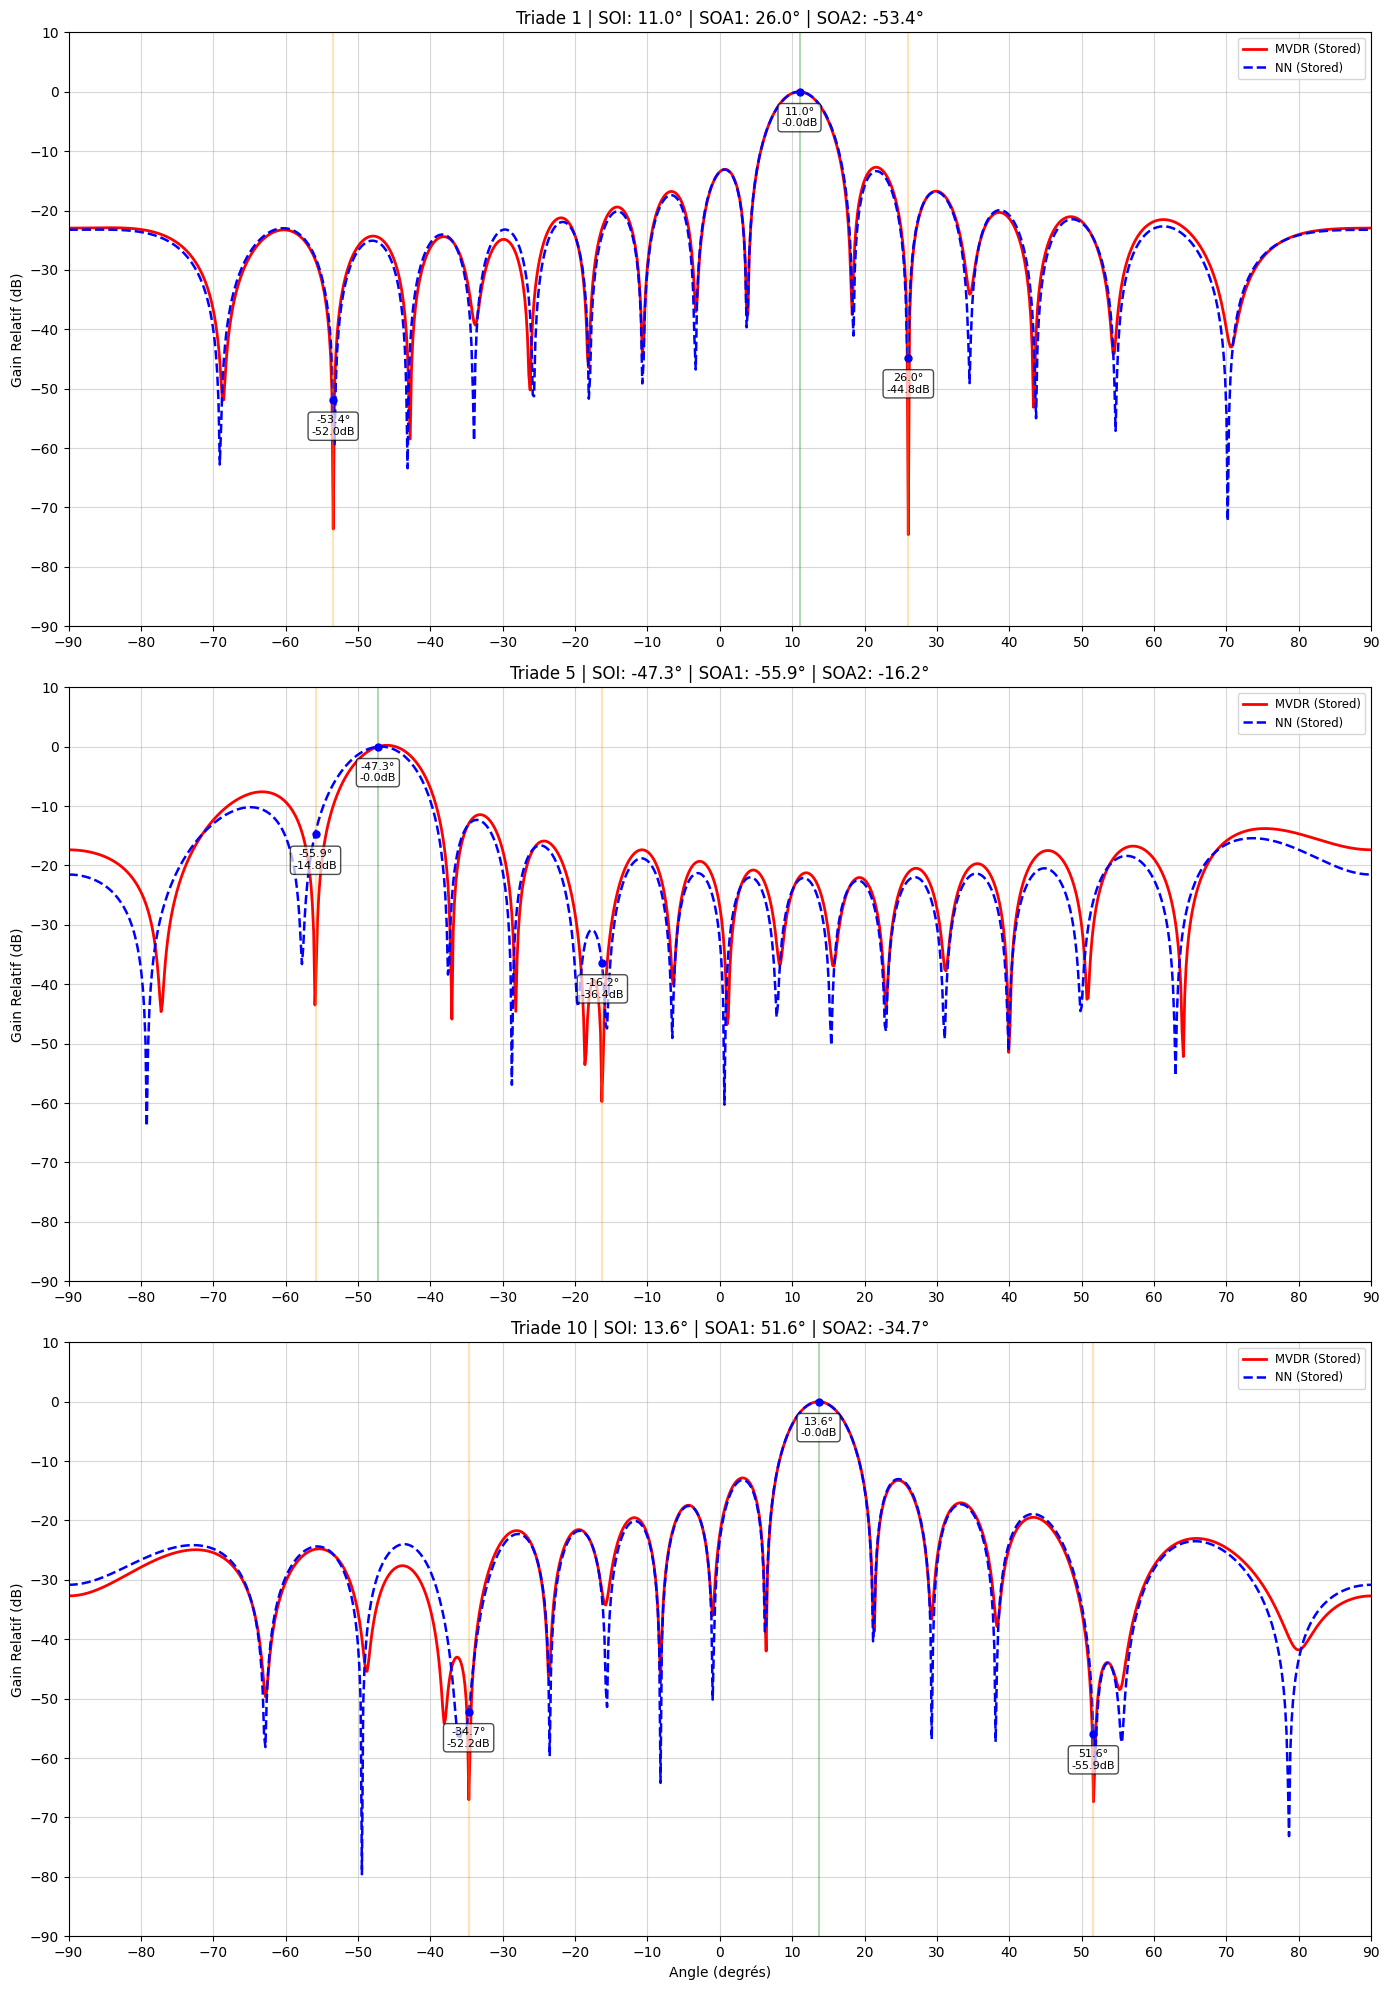

In [3]:
# =====================================================================================================================================
# --- AFFICHAGE DES DIAGRAMMES À PARTIR DES POIDS STOCKÉS ---
# =====================================================================================================================================

indices_plot = [0, 4, 9] 
fig, axs = plt.subplots(3, 1, figsize=(14, 20))

for i, idx in enumerate(indices_plot):
    soi_t, soa1_t, soa2_t = test_triads[idx]
    ax = axs[i]

    # RÉCUPÉRATION DES POIDS DÉJÀ CALCULÉS
    w_nn_c = all_weights[idx]['w_nn']
    w_mv_c = all_weights[idx]['w_mvdr']

    # --- SCAN NN (Réutilisation) ---
    p_nn = np.array([np.abs(np.vdot(w_nn_c, get_steering_vector(ang)))**2 for ang in angles_scan_NN])
    ref_nn = np.abs(np.vdot(w_nn_c, get_steering_vector(soi_t)))**2
    db_nn_plot = 10 * np.log10(p_nn / ref_nn + 1e-12)

    # --- SCAN MVDR (Réutilisation) ---
    p_mv = np.array([np.abs(np.vdot(w_mv_c, get_steering_vector(ang)))**2 for ang in theta_scan_deg])
    ref_mv = np.abs(np.vdot(w_mv_c, get_steering_vector(soi_t)))**2
    db_mv_plot = 10 * np.log10(p_mv / ref_mv + 1e-12)

    # --- AFFICHAGE ---
    ax.plot(theta_scan_deg, db_mv_plot, color='red', label='MVDR (Stored)', linewidth=2)
    ax.plot(angles_scan_NN, db_nn_plot, color='blue', linestyle='--', label='NN (Stored)', linewidth=1.8)

    # Annotations (SOI, SOA1, SOA2)
    triad = [soi_t, soa1_t, soa2_t]
    for j, ang in enumerate(triad):
        g_mv = get_gain_at_angle(ang, theta_scan_deg, db_mv_plot)
        g_nn = get_gain_at_angle(ang, angles_scan_NN, db_nn_plot)
        
        ax.axvline(ang, color=['green','orange','orange'][j], alpha=0.3)
        ax.plot(ang, g_nn, 'bo', markersize=5)
        ax.annotate(f"{ang:.1f}°\n{g_nn:.1f}dB", (ang, g_nn), xytext=(0, -25), 
                     textcoords="offset points", ha='center', fontsize=8, 
                     bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    # Mise en forme
    ax.set_title(f"Triade {idx+1} | SOI: {soi_t:.1f}° | SOA1: {soa1_t:.1f}° | SOA2: {soa2_t:.1f}°", fontsize=12)
    ax.set_ylabel("Gain Relatif (dB)")
    ax.set_ylim([-90, 5])
    ax.set_yticks(range(-90, 11, 10))
    ax.grid(True, linestyle='-', alpha=0.5)
    ax.set_xlim([-90, 90])
    ax.set_xticks(range(-90, 91, 10))
    ax.legend(loc='upper right', fontsize='small')

plt.xlabel("Angle (degrés)")
plt.tight_layout()
plt.show()